# PCA & SVD — From First Principles
### A complete, self-contained revision notebook

> **Goal**: Build PCA and SVD from scratch using only NumPy, understand *why* every step exists, and connect the two methods rigorously.

---
**Sections**
1. Motivation & Intuition
2. Linear Algebra Refresher (only what you need)
3. PCA — Step-by-Step from Scratch
4. SVD — Step-by-Step from Scratch
5. The Deep Connection Between PCA and SVD
6. Practical Application & sklearn Sanity-Check
7. Summary Cheat-Sheet

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

np.random.seed(42)
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#333',
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'font.size': 12,
})
ACCENT = ['#00f5d4', '#f72585', '#fee440', '#4cc9f0', '#7209b7']
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1 · Motivation & Intuition

**The curse of dimensionality**: As dimensions grow, data becomes sparse, distances lose meaning, and models overfit.

**The key insight**: Real data rarely fills all its dimensions uniformly. A 1000-pixel face image lives on a *manifold* of far fewer dimensions — the "face space".

**What we want**: Find a new coordinate system where:
- The axes point in directions of *maximum variance*
- We can throw away axes with tiny variance without losing much information
- The remaining axes are *uncorrelated* with each other

That is exactly what **PCA** does.

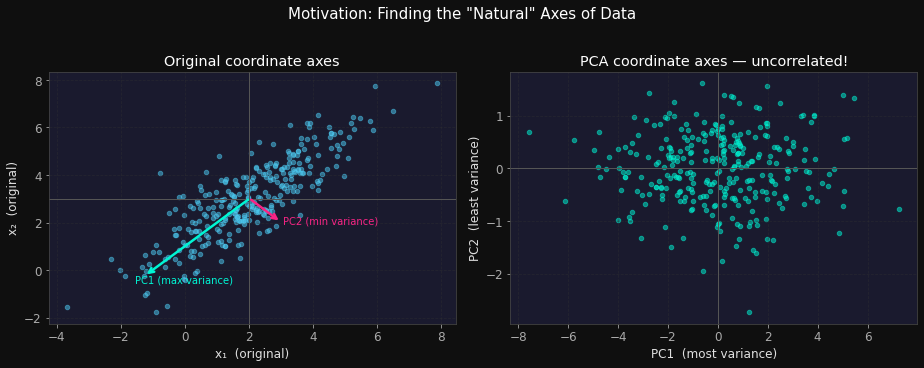

Variance along PC1: 5.27  |  PC2: 0.47
PC1 captures 91.9% of total variance


In [2]:
# Generate correlated 2D data to visualise the motivation
mean = [2, 3]
cov = [[3, 2.5], [2.5, 3]]        # strong positive correlation
X_demo = np.random.multivariate_normal(mean, cov, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Motivation: Finding the "Natural" Axes of Data', fontsize=15, color='white', y=1.02)

ax = axes[0]
ax.scatter(X_demo[:, 0], X_demo[:, 1], alpha=0.5, s=20, color=ACCENT[3])
ax.set_xlabel('x₁  (original)'); ax.set_ylabel('x₂  (original)')
ax.set_title('Original coordinate axes', color='white')
ax.axhline(3, color='#555', lw=1); ax.axvline(2, color='#555', lw=1)
ax.grid(True)

# Compute PCA manually for visualisation (explained in detail later)
Xc = X_demo - X_demo.mean(axis=0)
C = np.cov(Xc.T)
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

origin = X_demo.mean(axis=0)
for i, (ev, color, label) in enumerate(zip(eigvecs.T, [ACCENT[0], ACCENT[1]], ['PC1 (max variance)', 'PC2 (min variance)'])):
    scale = np.sqrt(eigvals[i]) * 2
    axes[0].annotate('', xy=origin + scale*ev, xytext=origin,
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    axes[0].text(*(origin + scale*ev*1.1), label, color=color, fontsize=10)

ax2 = axes[1]
X_pca = Xc @ eigvecs
ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20, color=ACCENT[0])
ax2.set_xlabel('PC1  (most variance)'); ax2.set_ylabel('PC2  (least variance)')
ax2.set_title('PCA coordinate axes — uncorrelated!', color='white')
ax2.axhline(0, color='#555', lw=1); ax2.axvline(0, color='#555', lw=1)
ax2.grid(True)

plt.tight_layout()
plt.show()
print(f'Variance along PC1: {eigvals[0]:.2f}  |  PC2: {eigvals[1]:.2f}')
print(f'PC1 captures {100*eigvals[0]/eigvals.sum():.1f}% of total variance')

---
## 2 · Linear Algebra Refresher

### 2.1 Covariance Matrix

For zero-mean data matrix **X** (shape `n × p`):

$$\mathbf{C} = \frac{1}{n-1}\mathbf{X}^\top\mathbf{X} \in \mathbb{R}^{p \times p}$$

- Diagonal: **variances** of each feature  
- Off-diagonal: **covariances** between features  
- **C** is always **symmetric positive semi-definite**

### 2.2 Eigendecomposition

For symmetric **C**: $\mathbf{C}\mathbf{v} = \lambda\mathbf{v}$

- **v** = eigenvector (a direction)
- **λ** = eigenvalue (how much **C** stretches along **v**)
- All eigenvectors of a real symmetric matrix are **orthogonal**
- All eigenvalues are **real and non-negative**

$$\mathbf{C} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^\top$$

### 2.3 SVD

For any matrix **A** (shape `m × n`):

$$\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$$

- **U** (`m × m`): left singular vectors (orthonormal)
- **Σ** (`m × n`): diagonal matrix of singular values σ₁ ≥ σ₂ ≥ … ≥ 0
- **V** (`n × n`): right singular vectors (orthonormal)

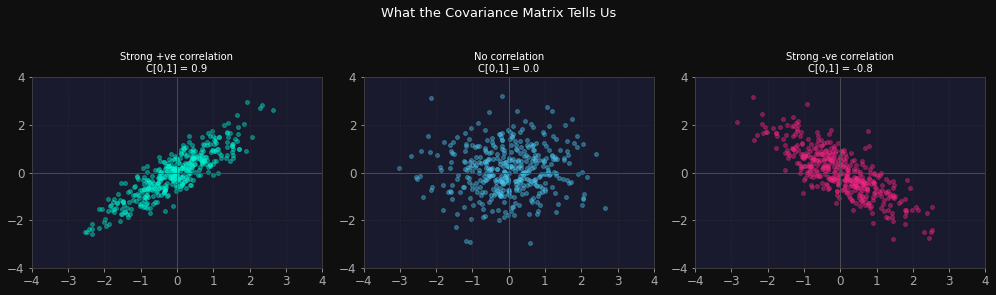

In [3]:
# ── Visualise what a covariance matrix encodes ──
A = np.array([[1.0, 0.9], [0.9, 1.0]])
B = np.array([[1.0, 0.0], [0.0, 1.0]])
C_neg = np.array([[1.0, -0.8], [-0.8, 1.0]])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Strong +ve correlation\nC[0,1] = 0.9', 
          'No correlation\nC[0,1] = 0.0',
          'Strong -ve correlation\nC[0,1] = -0.8']
colors = [ACCENT[0], ACCENT[3], ACCENT[1]]

for ax, cov_m, title, col in zip(axes, [A, B, C_neg], titles, colors):
    data = np.random.multivariate_normal([0, 0], cov_m, 400)
    ax.scatter(data[:,0], data[:,1], alpha=0.4, s=15, color=col)
    ax.set_title(title, color='white', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.axhline(0, color='#555', lw=0.8); ax.axvline(0, color='#555', lw=0.8)
    ax.grid(True)

fig.suptitle('What the Covariance Matrix Tells Us', fontsize=13, color='white', y=1.02)
plt.tight_layout()
plt.show()

---
## 3 · PCA — Step by Step from Scratch

### The 6 Steps of PCA

| Step | Operation | Why |
|------|-----------|-----|
| 1 | **Centre** the data (subtract mean) | Remove location; only shape matters |
| 2 | (Optionally) **scale** to unit variance | Make features comparable |
| 3 | Compute **covariance matrix** C | Encode all pairwise relationships |
| 4 | **Eigendecompose** C | Find directions of maximum variance |
| 5 | **Sort** eigenvectors by eigenvalue ↓ | Most important directions first |
| 6 | **Project** data onto top-k eigenvectors | Reduce dimensionality |

In [4]:
# ══════════════════════════════════════════════
#  Generate dataset: 200 samples, 3 features
#  (lives mostly on a 2D plane inside 3D space)
# ══════════════════════════════════════════════
n, p = 200, 3
true_cov = np.array([[4.0, 3.5, 1.0],
                     [3.5, 4.0, 0.5],
                     [1.0, 0.5, 0.3]])
X_raw = np.random.multivariate_normal([5, 3, 10], true_cov, n)

print('Data shape:', X_raw.shape)
print('Feature means:', X_raw.mean(axis=0).round(2))
print('Feature stds: ', X_raw.std(axis=0).round(2))

Data shape: (200, 3)
Feature means: [ 5.17  3.17 10.  ]
Feature stds:  [2.18 2.17 0.68]


C:\Users\pc\AppData\Local\Temp/ipykernel_24140/909087336.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_raw = np.random.multivariate_normal([5, 3, 10], true_cov, n)


Step 1 — Centred data
  Mean before: [ 5.174  3.174 10.   ]
  Mean after:  [0. 0. 0.]  (≈ 0)


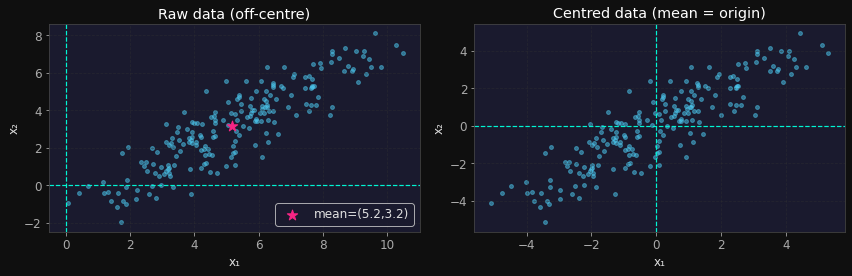

In [5]:
# ══════════════════════════════════════════════
#  STEP 1: Centre the data
# ══════════════════════════════════════════════
mu = X_raw.mean(axis=0)        # shape (p,)
X = X_raw - mu                 # broadcast subtract

print('Step 1 — Centred data')
print(f'  Mean before: {X_raw.mean(axis=0).round(3)}')
print(f'  Mean after:  {X.mean(axis=0).round(10)}  (≈ 0)')

# Visualise effect of centering
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes, [X_raw, X], ['Raw data (off-centre)', 'Centred data (mean = origin)']):
    ax.scatter(data[:,0], data[:,1], alpha=0.5, s=15, color=ACCENT[3])
    ax.axhline(0, color=ACCENT[0], lw=1.2, linestyle='--')
    ax.axvline(0, color=ACCENT[0], lw=1.2, linestyle='--')
    if data is X_raw:
        ax.scatter(*mu[:2], color=ACCENT[1], s=120, zorder=5, marker='*', label=f'mean=({mu[0]:.1f},{mu[1]:.1f})')
        ax.legend()
    ax.set_title(title, color='white'); ax.grid(True)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
plt.tight_layout(); plt.show()

In [6]:
# ══════════════════════════════════════════════
#  STEP 2: (Optional) Standardise
#  Divide by std so each feature has variance=1
#  → use when features have very different scales
# ══════════════════════════════════════════════

# For this demo, features are already on similar scale — skip standardisation
# But let's show what it looks like:
sigma = X.std(axis=0, ddof=1)
X_std = X / sigma

print('Step 2 — Standardised data (optional)')
print(f'  Std before standardisation: {X.std(axis=0).round(3)}')
print(f'  Std after  standardisation: {X_std.std(axis=0).round(3)}')
print('\n  ⚠️  We will proceed WITHOUT standardisation for this example')
print('     since all features are already on comparable scales.')

Step 2 — Standardised data (optional)
  Std before standardisation: [2.177 2.166 0.681]
  Std after  standardisation: [0.997 0.997 0.997]

  ⚠️  We will proceed WITHOUT standardisation for this example
     since all features are already on comparable scales.


Step 3 — Covariance Matrix  C  (shape: (3, 3) )
[[4.764 4.201 1.085]
 [4.201 4.715 0.613]
 [1.085 0.613 0.466]]

Max abs difference from np.cov: 2.6645352591003757e-15

Interpretation:
  Var(x₁) = 4.764  |  Cov(x₁,x₂) = 4.201
  Var(x₂) = 4.715  |  Cov(x₁,x₃) = 1.085
  Var(x₃) = 0.466  |  Cov(x₂,x₃) = 0.613


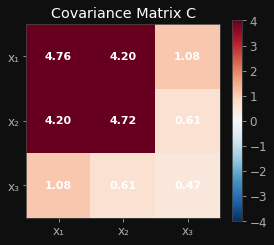

In [7]:
# ══════════════════════════════════════════════
#  STEP 3: Compute covariance matrix
# ══════════════════════════════════════════════

# Manual formula:  C = X^T X / (n-1)
C_manual = (X.T @ X) / (n - 1)       # shape (p, p)

# NumPy cross-check
C_numpy  = np.cov(X.T)                # should be identical

print('Step 3 — Covariance Matrix  C  (shape:', C_manual.shape, ')')
print(np.round(C_manual, 3))
print('\nMax abs difference from np.cov:', np.abs(C_manual - C_numpy).max())
print('\nInterpretation:')
print(f'  Var(x₁) = {C_manual[0,0]:.3f}  |  Cov(x₁,x₂) = {C_manual[0,1]:.3f}')
print(f'  Var(x₂) = {C_manual[1,1]:.3f}  |  Cov(x₁,x₃) = {C_manual[0,2]:.3f}')
print(f'  Var(x₃) = {C_manual[2,2]:.3f}  |  Cov(x₂,x₃) = {C_manual[1,2]:.3f}')

# Visualise covariance matrix as heatmap
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(C_manual, cmap='RdBu_r', vmin=-4, vmax=4)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{C_manual[i,j]:.2f}', ha='center', va='center', 
                color='white', fontsize=11, fontweight='bold')
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(['x₁','x₂','x₃']); ax.set_yticklabels(['x₁','x₂','x₃'])
ax.set_title('Covariance Matrix C', color='white')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [8]:
# ══════════════════════════════════════════════
#  STEP 4: Eigendecomposition of C
# ══════════════════════════════════════════════

# np.linalg.eigh is designed for symmetric matrices — more numerically stable
eigenvalues, eigenvectors = np.linalg.eigh(C_manual)

print('Step 4 — Eigendecomposition')
print('Raw eigenvalues (unsorted):', eigenvalues.round(4))
print('\nEigenvectors (columns = principal directions):')
print(eigenvectors.round(4))

print('\nVerification: C @ v = λ @ v ?')
for i in range(p):
    lhs = C_manual @ eigenvectors[:, i]
    rhs = eigenvalues[i] * eigenvectors[:, i]
    print(f'  PC{i+1}: max error = {np.abs(lhs - rhs).max():.2e}  ✓')

Step 4 — Eigendecomposition
Raw eigenvalues (unsorted): [0.0704 0.7673 9.1075]

Eigenvectors (columns = principal directions):
[[-0.4821 -0.5186 -0.7061]
 [ 0.3289  0.6399 -0.6945]
 [ 0.812  -0.5671 -0.1379]]

Verification: C @ v = λ @ v ?
  PC1: max error = 1.11e-16  ✓
  PC2: max error = 7.22e-16  ✓
  PC3: max error = 8.88e-16  ✓


Step 5 — Sorted eigenvalues (= explained variance)
  PC1: λ = 9.1075  |  91.6% variance  |  cumulative = 91.6%
  PC2: λ = 0.7673  |  7.7% variance  |  cumulative = 99.3%
  PC3: λ = 0.0704  |  0.7% variance  |  cumulative = 100.0%


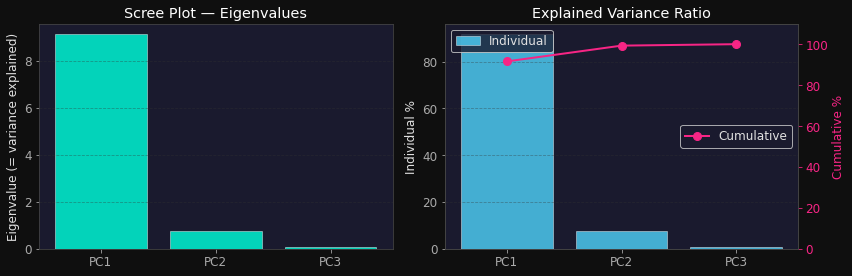


→ Keeping top 2 PCs captures 99.3% of variance
  We can drop PC3 and only lose 0.7% of information


In [9]:
# ══════════════════════════════════════════════
#  STEP 5: Sort by eigenvalue (descending)
# ══════════════════════════════════════════════

sort_idx    = np.argsort(eigenvalues)[::-1]      # descending order
eigvals_s   = eigenvalues[sort_idx]
eigvecs_s   = eigenvectors[:, sort_idx]          # columns = principal components

explained_var_ratio = eigvals_s / eigvals_s.sum()
cumulative_var      = np.cumsum(explained_var_ratio)

print('Step 5 — Sorted eigenvalues (= explained variance)')
for i, (ev, evr, cv) in enumerate(zip(eigvals_s, explained_var_ratio, cumulative_var)):
    print(f'  PC{i+1}: λ = {ev:.4f}  |  {evr*100:.1f}% variance  |  cumulative = {cv*100:.1f}%')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pcs = [f'PC{i+1}' for i in range(p)]

axes[0].bar(pcs, eigvals_s, color=ACCENT[0], alpha=0.85, edgecolor='white', lw=0.5)
axes[0].set_title('Scree Plot — Eigenvalues', color='white')
axes[0].set_ylabel('Eigenvalue (= variance explained)')
axes[0].grid(True, axis='y')

axes[1].bar(pcs, explained_var_ratio * 100, color=ACCENT[3], alpha=0.85, label='Individual', edgecolor='white', lw=0.5)
ax1b = axes[1].twinx()
ax1b.plot(pcs, cumulative_var * 100, color=ACCENT[1], marker='o', ms=8, lw=2, label='Cumulative')
ax1b.set_ylabel('Cumulative %', color=ACCENT[1])
ax1b.tick_params(colors=ACCENT[1])
ax1b.set_ylim(0, 110)
axes[1].set_title('Explained Variance Ratio', color='white')
axes[1].set_ylabel('Individual %')
axes[1].grid(True, axis='y')
axes[1].legend(loc='upper left'); ax1b.legend(loc='center right')

plt.tight_layout(); plt.show()

print(f'\n→ Keeping top 2 PCs captures {cumulative_var[1]*100:.1f}% of variance')
print(f'  We can drop PC3 and only lose {(1-cumulative_var[1])*100:.1f}% of information')

In [10]:
# ══════════════════════════════════════════════
#  STEP 6: Project data onto top-k components
# ══════════════════════════════════════════════

k = 2                                   # keep 2 principal components
W = eigvecs_s[:, :k]                    # projection matrix: (p × k) = (3 × 2)

X_pca_manual = X @ W                    # (n × p) @ (p × k) = (n × k)

print('Step 6 — Projection')
print(f'  W  (loading matrix) shape: {W.shape}')
print(f'  X  (centred)        shape: {X.shape}')
print(f'  X_pca               shape: {X_pca_manual.shape}')
print('\nProjection matrix W (columns = principal directions):')
print(W.round(4))

# Verify that projected components are uncorrelated
C_projected = np.cov(X_pca_manual.T)
print(f'\nCovariance of projected data (should be diagonal):')
print(C_projected.round(6))

Step 6 — Projection
  W  (loading matrix) shape: (3, 2)
  X  (centred)        shape: (200, 3)
  X_pca               shape: (200, 2)

Projection matrix W (columns = principal directions):
[[-0.7061 -0.5186]
 [-0.6945  0.6399]
 [-0.1379 -0.5671]]

Covariance of projected data (should be diagonal):
[[ 9.107521 -0.      ]
 [-0.        0.767322]]


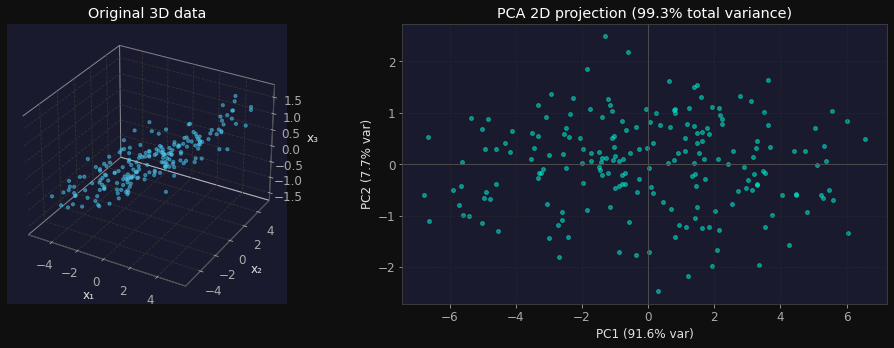

In [11]:
# Visualise the 2D projection
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 2, figure=fig)

# 3D original
ax3d = fig.add_subplot(gs[0], projection='3d')
ax3d.scatter(X[:,0], X[:,1], X[:,2], alpha=0.5, s=10, color=ACCENT[3])
ax3d.set_title('Original 3D data', color='white')
ax3d.set_xlabel('x₁'); ax3d.set_ylabel('x₂'); ax3d.set_zlabel('x₃')
ax3d.xaxis.pane.fill = False; ax3d.yaxis.pane.fill = False; ax3d.zaxis.pane.fill = False

# 2D projection
ax2d = fig.add_subplot(gs[1])
ax2d.scatter(X_pca_manual[:,0], X_pca_manual[:,1], alpha=0.5, s=15, color=ACCENT[0])
ax2d.set_xlabel(f'PC1 ({explained_var_ratio[0]*100:.1f}% var)')
ax2d.set_ylabel(f'PC2 ({explained_var_ratio[1]*100:.1f}% var)')
ax2d.set_title(f'PCA 2D projection ({cumulative_var[1]*100:.1f}% total variance)', color='white')
ax2d.axhline(0, color='#555', lw=0.8); ax2d.axvline(0, color='#555', lw=0.8)
ax2d.grid(True)

plt.tight_layout(); plt.show()

Reconstruction Quality
  MSE:             0.023355
  Total variance:  9.8955
  Info retained:   99.29%
  Info lost:       0.71%


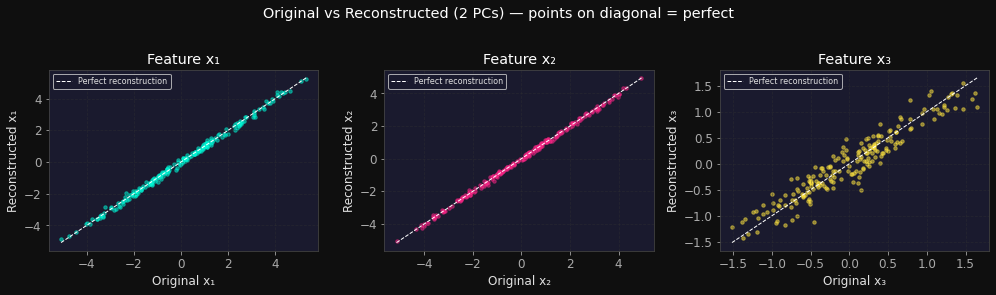

In [12]:
# ══════════════════════════════════════════════
#  RECONSTRUCTION & Information Loss
# ══════════════════════════════════════════════

# Reconstruct back to original space
X_reconstructed = X_pca_manual @ W.T        # (n×k) @ (k×p) = (n×p)

# Reconstruction error
error = X - X_reconstructed
mse   = np.mean(error**2)
total_var = np.var(X, axis=0).sum()
pct_lost = (1 - cumulative_var[k-1]) * 100

print('Reconstruction Quality')
print(f'  MSE:             {mse:.6f}')
print(f'  Total variance:  {total_var:.4f}')
print(f'  Info retained:   {cumulative_var[k-1]*100:.2f}%')
print(f'  Info lost:       {pct_lost:.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (col, title) in enumerate(zip(['x₁','x₂','x₃'], 
                                      ['Feature x₁', 'Feature x₂', 'Feature x₃'])):
    axes[i].scatter(X[:, i], X_reconstructed[:, i], alpha=0.5, s=12, color=ACCENT[i])
    lims = [min(X[:,i].min(), X_reconstructed[:,i].min()), 
            max(X[:,i].max(), X_reconstructed[:,i].max())]
    axes[i].plot(lims, lims, '--', color='white', lw=1, label='Perfect reconstruction')
    axes[i].set_xlabel(f'Original {col}'); axes[i].set_ylabel(f'Reconstructed {col}')
    axes[i].set_title(title, color='white'); axes[i].grid(True); axes[i].legend(fontsize=8)

fig.suptitle('Original vs Reconstructed (2 PCs) — points on diagonal = perfect', 
             color='white', y=1.02)
plt.tight_layout(); plt.show()

---
## 4 · SVD — Step by Step from Scratch

### What is SVD?

**Singular Value Decomposition** is the most important factorisation in linear algebra. For any matrix **A** (m × n):

$$\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$$

| Matrix | Shape | Meaning |
|--------|-------|---------|
| **U** | m × m | Left singular vectors — orthonormal basis for the *row* space |
| **Σ** | m × n | Diagonal — singular values σᵢ = √λᵢ, sorted ↓ |
| **V** | n × n | Right singular vectors — orthonormal basis for the *column* space |

### Geometric Interpretation

Any linear transformation **A** can be decomposed as:
1. **V^T** — rotate the input
2. **Σ** — stretch/compress along axes
3. **U** — rotate the output

SVD reveals the *fundamental geometry* of a linear map.

In [13]:
# ══════════════════════════════════════════════
#  SVD from first principles
#  (Deriving U, Σ, V from eigendecomposition)
# ══════════════════════════════════════════════

# Use our centred data X (n × p = 200 × 3)
A = X.copy()
m, n_cols = A.shape

print(f'Matrix A shape: {A.shape}  (m={m}, n={n_cols})')
print('\n--- Computing SVD from first principles ---\n')

# ── Step 1: Compute A^T A (this is proportional to the covariance matrix)
AtA = A.T @ A                           # shape (p × p)
print('A^T A (shape', AtA.shape, '):')
print(AtA.round(2))

# ── Step 2: Eigendecompose A^T A → gives V and σ²
evals_AtA, evecs_AtA = np.linalg.eigh(AtA)
idx = np.argsort(evals_AtA)[::-1]
evals_AtA = evals_AtA[idx]
evecs_AtA = evecs_AtA[:, idx]

# V = eigenvectors of A^T A
V_manual = evecs_AtA
print('\nV (right singular vectors):')
print(V_manual.round(4))

# Singular values = sqrt of eigenvalues of A^T A
singular_values = np.sqrt(np.maximum(evals_AtA, 0))   # clip tiny negatives due to float errors
print('\nSingular values σ:', singular_values.round(4))
print('  (= sqrt of eigenvalues of A^T A):', np.sqrt(evals_AtA).round(4))

Matrix A shape: (200, 3)  (m=200, n=3)

--- Computing SVD from first principles ---

A^T A (shape (3, 3) ):
[[948.01 835.95 215.89]
 [835.95 938.29 121.91]
 [215.89 121.91  92.81]]

V (right singular vectors):
[[-0.7061 -0.5186 -0.4821]
 [-0.6945  0.6399  0.3289]
 [-0.1379 -0.5671  0.812 ]]

Singular values σ: [42.5723 12.3571  3.7434]
  (= sqrt of eigenvalues of A^T A): [42.5723 12.3571  3.7434]


In [14]:
# ── Step 3: Compute U from A and V
#   A = U Σ V^T  →  U_i = (1/σ_i) * A * v_i

r = n_cols  # rank (number of non-zero singular values)
U_manual = np.zeros((m, r))

for i in range(r):
    if singular_values[i] > 1e-10:
        U_manual[:, i] = (A @ V_manual[:, i]) / singular_values[i]

# Build Σ matrix
Sigma_manual = np.zeros((m, n_cols))
for i in range(r):
    Sigma_manual[i, i] = singular_values[i]

print('U  shape:', U_manual.shape)
print('Σ  shape:', Sigma_manual.shape)
print('V  shape:', V_manual.shape)

# ── Verify: A ≈ U Σ V^T
A_reconstructed = U_manual @ Sigma_manual[:r, :] @ V_manual.T
print(f'\nVerification: max|A - UΣV^T| = {np.abs(A - A_reconstructed).max():.2e}  ✓')

# ── Compare with NumPy SVD
U_np, s_np, Vt_np = np.linalg.svd(A, full_matrices=False)
print(f'NumPy singular values: {s_np.round(4)}')
print(f'Manual singular values: {singular_values.round(4)}')

# Note: sign of singular vectors can flip, compare absolute values
print(f'\nSingular values match: {np.allclose(np.abs(singular_values), np.abs(s_np))}  ✓')

U  shape: (200, 3)
Σ  shape: (200, 3)
V  shape: (3, 3)

Verification: max|A - UΣV^T| = 1.78e-15  ✓
NumPy singular values: [42.5723 12.3571  3.7434]
Manual singular values: [42.5723 12.3571  3.7434]

Singular values match: True  ✓


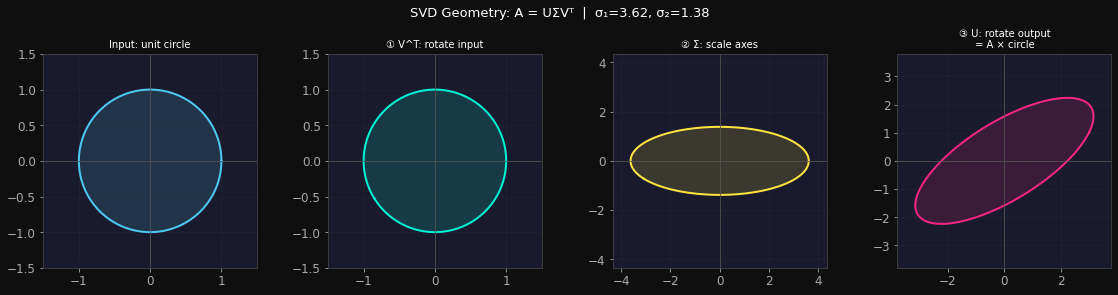

A = [[3. 1.]
 [1. 2.]]
U = [[-0.8507 -0.5257]
 [-0.5257  0.8507]]
Σ = diag([3.618 1.382])
V = [[-0.8507 -0.5257]
 [-0.5257  0.8507]]


In [15]:
# ══════════════════════════════════════════════
#  Geometric Visualisation: SVD as 3 operations
# ══════════════════════════════════════════════

# Work in 2D for clarity
A2 = np.array([[3.0, 1.0],
               [1.0, 2.0]])

U2, s2, Vt2 = np.linalg.svd(A2)
V2 = Vt2.T

# Create a unit circle of vectors
theta = np.linspace(0, 2*np.pi, 200)
circle = np.stack([np.cos(theta), np.sin(theta)])   # (2, 200)

# Apply each step
step1 = V2.T @ circle           # Rotate by V^T
step2 = np.diag(s2) @ step1    # Scale by Σ
step3 = U2 @ step2             # Rotate by U (= A @ circle)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plots = [
    (circle, 'Input: unit circle', ACCENT[3]),
    (step1,  '① V^T: rotate input', ACCENT[0]),
    (step2,  '② Σ: scale axes', ACCENT[2]),
    (step3,  '③ U: rotate output\n= A × circle', ACCENT[1]),
]

for ax, (data, title, color) in zip(axes, plots):
    ax.plot(data[0], data[1], color=color, lw=2)
    ax.fill(data[0], data[1], alpha=0.15, color=color)
    ax.set_aspect('equal'); ax.grid(True)
    ax.axhline(0, color='#555', lw=0.8); ax.axvline(0, color='#555', lw=0.8)
    ax.set_title(title, color='white', fontsize=10)
    lim = max(np.abs(data).max() * 1.2, 1.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

fig.suptitle(f'SVD Geometry: A = UΣVᵀ  |  σ₁={s2[0]:.2f}, σ₂={s2[1]:.2f}', 
             color='white', fontsize=13)
plt.tight_layout(); plt.show()

print(f'A = {A2}')
print(f'U = {U2.round(4)}')
print(f'Σ = diag({s2.round(4)})')
print(f'V = {V2.round(4)}')

---
## 4.1 · Truncated SVD — Low-Rank Approximation

One of SVD's most powerful properties: **the best rank-k approximation** to any matrix.

$$\mathbf{A}_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^\top$$

This is the Eckart–Young theorem: no other rank-k matrix is closer to **A** in Frobenius norm.

C:\Users\pc\AppData\Local\Temp/ipykernel_24140/2097031740.py:35: UserWarning: Attempted to set non-positive top ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax.imshow(A_k, cmap='plasma')


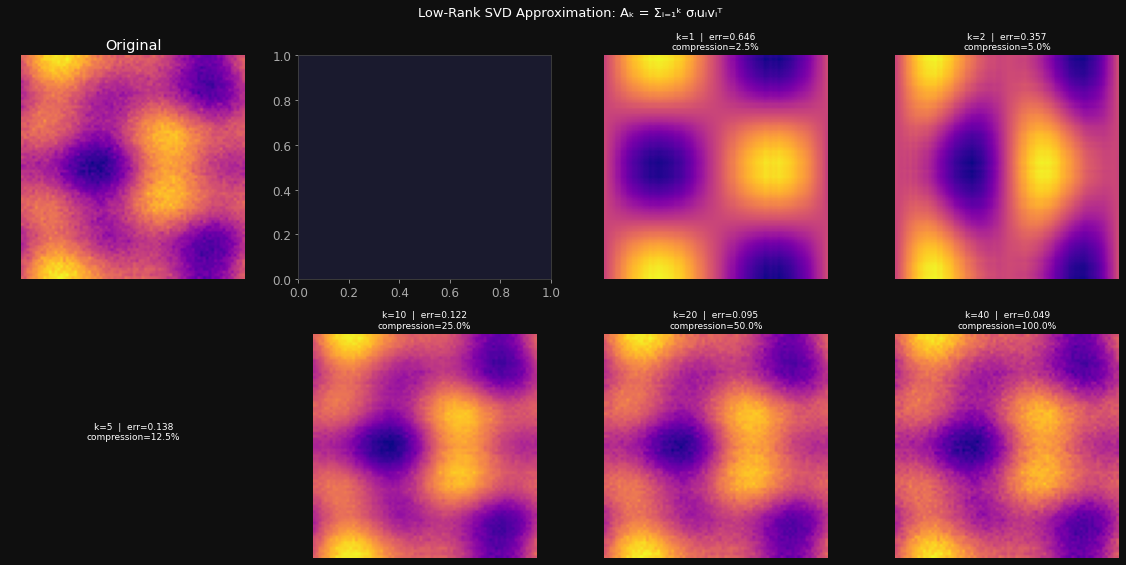

In [16]:
# ══════════════════════════════════════════════
#  Truncated SVD applied to an image
# ══════════════════════════════════════════════

# Generate a synthetic grayscale image-like matrix
np.random.seed(7)
xx, yy = np.meshgrid(np.linspace(0, 2*np.pi, 80), np.linspace(0, 2*np.pi, 80))
img = (np.sin(xx) * np.cos(yy) + 
       0.5 * np.sin(2*xx) + 
       0.3 * np.cos(3*yy) +
       0.1 * np.random.randn(80, 80))

U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
k_values = [1, 2, 5, 10, 20, 40, img.shape[0]]

axes[0, 0].imshow(img, cmap='plasma')
axes[0, 0].set_title('Original', color='white')
axes[0, 0].axis('off')

# Singular value decay
axes[1, 0].semilogy(s_img, color=ACCENT[0], lw=2)
axes[1, 0].set_title('Singular value decay', color='white')
axes[1, 0].set_xlabel('Index'); axes[1, 0].set_ylabel('σ (log scale)')
axes[1, 0].grid(True)

for ax, k in zip(axes.flat[2:], k_values[:-1]):
    # Low-rank approximation: sum of outer products
    A_k = (U_img[:, :k] * s_img[:k]) @ Vt_img[:k, :]
    
    err = np.linalg.norm(img - A_k, 'fro') / np.linalg.norm(img, 'fro')
    compression = k * (img.shape[0] + img.shape[1]) / (img.shape[0] * img.shape[1])
    
    ax.imshow(A_k, cmap='plasma')
    ax.set_title(f'k={k}  |  err={err:.3f}\ncompression={compression:.1%}', 
                 color='white', fontsize=9)
    ax.axis('off')

fig.suptitle('Low-Rank SVD Approximation: Aₖ = Σᵢ₌₁ᵏ σᵢuᵢvᵢᵀ', 
             color='white', fontsize=13)
plt.tight_layout(); plt.show()

---
## 5 · The Deep Connection Between PCA and SVD

This is the key insight that unifies both methods.

**Given centred data X (n × p), with SVD: X = UΣVᵀ**

The covariance matrix is:
$$\mathbf{C} = \frac{1}{n-1}\mathbf{X}^\top\mathbf{X} = \frac{1}{n-1}(\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top)^\top(\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top) = \mathbf{V}\frac{\boldsymbol{\Sigma}^2}{n-1}\mathbf{V}^\top$$

Comparing with the eigendecomposition **C = VΛVᵀ**:

| PCA quantity | SVD equivalent |
|-------------|----------------|
| Eigenvectors **V** of **C** | Right singular vectors **V** of **X** |
| Eigenvalues λᵢ | σᵢ² / (n−1) |
| PCA scores **XV** | Left singular vectors **UΣ** |

**Bottom line**: PCA via SVD is numerically superior — avoids forming X^TX explicitly.

In [17]:
# ══════════════════════════════════════════════
#  Prove the equivalence numerically
# ══════════════════════════════════════════════

print('='*60)
print('PROVING PCA ≡ SVD')
print('='*60)

# Method 1: PCA via eigendecomposition of covariance
C_eig  = (X.T @ X) / (n - 1)
evals, evecs = np.linalg.eigh(C_eig)
idx = np.argsort(evals)[::-1]
pca_eigenvalues = evals[idx]
pca_components  = evecs[:, idx]
pca_scores      = X @ pca_components

# Method 2: PCA via SVD of X
U_svd, s_svd, Vt_svd = np.linalg.svd(X, full_matrices=False)
svd_components  = Vt_svd.T                         # V = right singular vectors
svd_eigenvalues = s_svd**2 / (n - 1)              # λ = σ²/(n-1)
svd_scores      = U_svd * s_svd                    # PCA scores = UΣ

print('\nPrincipal directions (may differ by sign, compare |.|):')
print('  PCA via eigh:  ', np.abs(pca_components[:, 0]).round(4))
print('  PCA via SVD:   ', np.abs(svd_components[:, 0]).round(4))
print('  Match:', np.allclose(np.abs(pca_components), np.abs(svd_components)))

print('\nEigenvalues (= variance per PC):')
print('  Via eigh:', pca_eigenvalues.round(4))
print('  Via SVD: ', svd_eigenvalues.round(4))
print('  Match:', np.allclose(pca_eigenvalues, svd_eigenvalues))

print('\nScores variance (same info, different sign convention):')
print('  Via eigh score var:', np.var(pca_scores, axis=0).round(4))
print('  Via SVD  score var:', np.var(svd_scores, axis=0).round(4))

print('\n✅ PCA and SVD produce identical results!')

PROVING PCA ≡ SVD

Principal directions (may differ by sign, compare |.|):
  PCA via eigh:   [0.7061 0.6945 0.1379]
  PCA via SVD:    [0.7061 0.6945 0.1379]
  Match: True

Eigenvalues (= variance per PC):
  Via eigh: [9.1075 0.7673 0.0704]
  Via SVD:  [9.1075 0.7673 0.0704]
  Match: True

Scores variance (same info, different sign convention):
  Via eigh score var: [9.062  0.7635 0.0701]
  Via SVD  score var: [9.062  0.7635 0.0701]

✅ PCA and SVD produce identical results!


In [18]:
# ══════════════════════════════════════════════
#  Why SVD is preferred in practice
# ══════════════════════════════════════════════

print('Why sklearn and scipy use SVD (not eigendecomposition):\n')

# Numerical stability demo
# Ill-conditioned matrix — eigendecomposition of X^TX amplifies errors
eps = 1e-7
X_illcond = np.array([[1.0, 1.0], 
                      [1.0, 1.0 + eps],
                      [1.0, 1.0 + 2*eps]])

# Via covariance
XtX = X_illcond.T @ X_illcond
print('X^T X condition number (amplifies errors!):')
print(f'  cond(X^T X) = {np.linalg.cond(XtX):.2e}')
print(f'  cond(X)     = {np.linalg.cond(X_illcond):.2e}')
print('\n→ Computing SVD of X directly is more numerically stable than')
print('  eigendecomposing X^T X (which squares the condition number!)')

print('\nSummary: When to use each approach')
print('  ├── n >> p  (many samples, few features): eigh(X^T X) is fine')
print('  ├── p >> n  (few samples, many features): eigh(X X^T) or SVD(X)')
print('  └── General: SVD(X) — always safe, sklearn default')

Why sklearn and scipy use SVD (not eigendecomposition):

X^T X condition number (amplifies errors!):
  cond(X^T X) = 5.92e+14
  cond(X)     = 2.45e+07

→ Computing SVD of X directly is more numerically stable than
  eigendecomposing X^T X (which squares the condition number!)

Summary: When to use each approach
  ├── n >> p  (many samples, few features): eigh(X^T X) is fine
  ├── p >> n  (few samples, many features): eigh(X X^T) or SVD(X)
  └── General: SVD(X) — always safe, sklearn default


---
## 6 · Practical Application & sklearn Sanity-Check

Iris Dataset PCA
Shape: (150, 4) → (150, 2)

Our explained variance:     [0.72962445 0.22850762]
sklearn explained variance: [0.72962445 0.22850762]


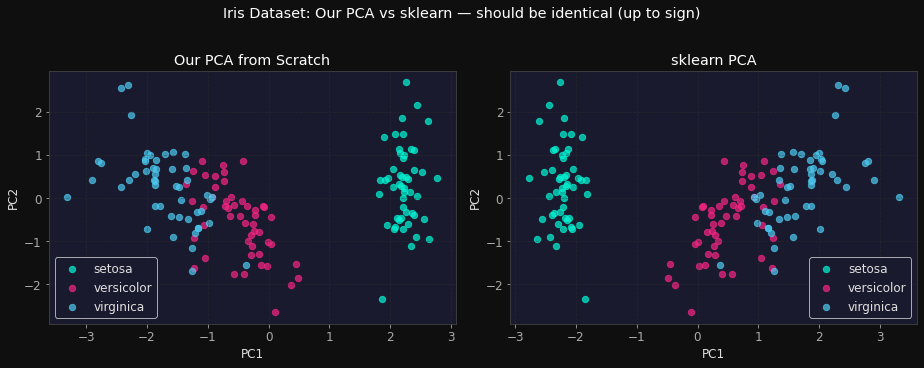

In [19]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# ── Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names

# ── Our from-scratch PCA
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

mu_iris = X_scaled.mean(axis=0)
C_iris  = np.cov(X_scaled.T)
evals_iris, evecs_iris = np.linalg.eigh(C_iris)
idx = np.argsort(evals_iris)[::-1]
W_iris = evecs_iris[:, idx][:, :2]
X_pca_scratch = X_scaled @ W_iris

# ── sklearn PCA (should match)
pca_sk = PCA(n_components=2)
X_pca_sk = pca_sk.fit_transform(X_scaled)

print('Iris Dataset PCA')
print(f'Shape: {X_iris.shape} → {X_pca_scratch.shape}')
print(f'\nOur explained variance:     {evals_iris[idx][:2] / evals_iris.sum()}')
print(f'sklearn explained variance: {pca_sk.explained_variance_ratio_}')

# Plot
colors_iris = [ACCENT[0], ACCENT[1], ACCENT[3]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for method, X_proj, ax, title in [
    ('scratch', X_pca_scratch, axes[0], 'Our PCA from Scratch'),
    ('sklearn', X_pca_sk, axes[1], 'sklearn PCA'),
]:
    for cls, color, label in zip([0,1,2], colors_iris, iris.target_names):
        mask = y_iris == cls
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1], 
                   color=color, alpha=0.7, s=40, label=label)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(title, color='white')
    ax.legend(); ax.grid(True)

fig.suptitle('Iris Dataset: Our PCA vs sklearn — should be identical (up to sign)', 
             color='white', y=1.02)
plt.tight_layout(); plt.show()

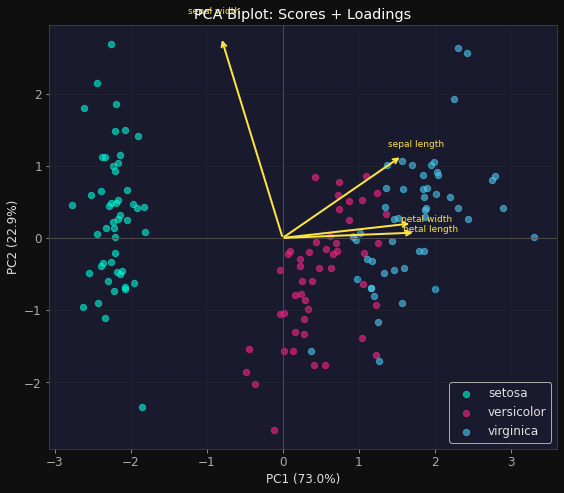

Loadings (how much each feature contributes to each PC):
Feature                   PC1        PC2
  sepal length (cm)        +0.5211     +0.3774
  sepal width (cm)         -0.2693     +0.9233
  petal length (cm)        +0.5804     +0.0245
  petal width (cm)         +0.5649     +0.0669


In [20]:
# ══════════════════════════════════════════════
#  Biplot: Loadings + Scores together
# ══════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 7))

for cls, color, label in zip([0,1,2], colors_iris, iris.target_names):
    mask = y_iris == cls
    ax.scatter(X_pca_sk[mask, 0], X_pca_sk[mask, 1],
               color=color, alpha=0.6, s=40, label=label)

# Draw loading arrows
loadings = pca_sk.components_.T  # (4, 2)
scale = 3.0
for i, (feature, loading) in enumerate(zip(feature_names, loadings)):
    ax.annotate('', xy=loading*scale, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=ACCENT[2], lw=2))
    ax.text(loading[0]*scale*1.12, loading[1]*scale*1.12, 
            feature.replace(' (cm)', ''), color=ACCENT[2], fontsize=9, ha='center')

ax.axhline(0, color='#555', lw=0.8); ax.axvline(0, color='#555', lw=0.8)
ax.set_xlabel(f'PC1 ({pca_sk.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_sk.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Biplot: Scores + Loadings', color='white')
ax.legend()
ax.grid(True)
plt.tight_layout(); plt.show()

print('Loadings (how much each feature contributes to each PC):')
print('Feature'.ljust(25), 'PC1'.ljust(10), 'PC2')
for f, l in zip(feature_names, loadings):
    print(f'  {f.ljust(23)}  {l[0]:+.4f}     {l[1]:+.4f}')

---
## 7 · Summary Cheat-Sheet

### PCA Algorithm (from scratch)

```
Input: X  (n × p)

1. Centre:     X ← X - mean(X, axis=0)
2. [Scale]:    X ← X / std(X, axis=0)     # optional
3. Cov:        C ← X^T X / (n-1)          # (p × p)
4. Eigen:      C = V Λ V^T                 # eigh(C)
5. Sort:       λ₁ ≥ λ₂ ≥ … ≥ λₚ
6. Project:    Z ← X @ V[:, :k]           # (n × k)

Output: Z  (n × k),  k << p
```

### SVD Facts

```
A = U Σ V^T

• U:  left singular vectors  (eigenvectors of A A^T)
• V:  right singular vectors (eigenvectors of A^T A)
• σᵢ: singular values = sqrt(eigenvalues of A^T A)

Low-rank approx:  Aₖ = Σᵢ₌₁ᵏ σᵢ uᵢ vᵢ^T  (Eckart-Young)
```

### PCA ↔ SVD Equivalence

```
X = U Σ V^T  (SVD of centred X)

• V           = principal directions  (= eigenvectors of C)
• σᵢ²/(n-1)  = eigenvalues of C      (= variance per PC)
• U Σ         = PCA scores
```

### Key Intuitions

| Question | Answer |
|----------|--------|
| What does an eigenvalue mean in PCA? | Variance captured by that PC |
| What does a singular value mean in SVD? | √(variance × (n-1)) — the "stretch" |
| Why centre data? | Covariance is defined around the mean |
| Why not just use PCA always? | SVD is more numerically stable; works when X^TX is singular |
| When to standardise? | When features have very different units/scales |
| How many PCs to keep? | Elbow on scree plot, or 90-95% cumulative variance |

In [21]:
# ══════════════════════════════════════════════
#  Final: Full self-contained PCA class
# ══════════════════════════════════════════════

class PCA_scratch:
    """
    Principal Component Analysis from first principles.
    Uses SVD of data matrix (sklearn's approach) for numerical stability.
    """
    def __init__(self, n_components=None, standardise=False):
        self.n_components = n_components
        self.standardise  = standardise

    def fit(self, X):
        n, p = X.shape
        # 1. Centre
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        # 2. Scale (optional)
        self.scale_ = Xc.std(axis=0, ddof=1) if self.standardise else np.ones(p)
        Xc = Xc / self.scale_
        # 3-5. SVD
        _, s, Vt = np.linalg.svd(Xc, full_matrices=False)
        self.components_ = Vt                     # (p, p) — rows are PCs
        self.explained_variance_ = s**2 / (n - 1)
        self.explained_variance_ratio_ = self.explained_variance_ / self.explained_variance_.sum()
        self.singular_values_ = s
        k = self.n_components or p
        self.components_ = Vt[:k]                # keep top-k
        return self

    def transform(self, X):
        Xc = (X - self.mean_) / self.scale_
        return Xc @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        return Z @ self.components_ * self.scale_ + self.mean_


# Test it
pca_our = PCA_scratch(n_components=2, standardise=True)
Z_our   = pca_our.fit_transform(X_iris)

pca_ref = PCA(n_components=2)
Z_ref   = pca_ref.fit_transform(StandardScaler().fit_transform(X_iris))

print('Our PCA class vs sklearn:')
print(f'  Explained variance ratio (ours):    {pca_our.explained_variance_ratio_[:2].round(4)}')
print(f'  Explained variance ratio (sklearn): {pca_ref.explained_variance_ratio_.round(4)}')

# Scores match up to sign flips
corrs = [np.abs(np.corrcoef(Z_our[:, i], Z_ref[:, i])[0,1]) for i in range(2)]
print(f'\n  Correlation of scores (|r|, expect ≈1): PC1={corrs[0]:.6f}, PC2={corrs[1]:.6f}')
print('\n✅ Our PCA class matches sklearn!')

Our PCA class vs sklearn:
  Explained variance ratio (ours):    [0.7296 0.2285]
  Explained variance ratio (sklearn): [0.7296 0.2285]

  Correlation of scores (|r|, expect ≈1): PC1=1.000000, PC2=1.000000

✅ Our PCA class matches sklearn!
